In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import re

Found 6 elements in ../.data/measurements-public/gg_coverage/


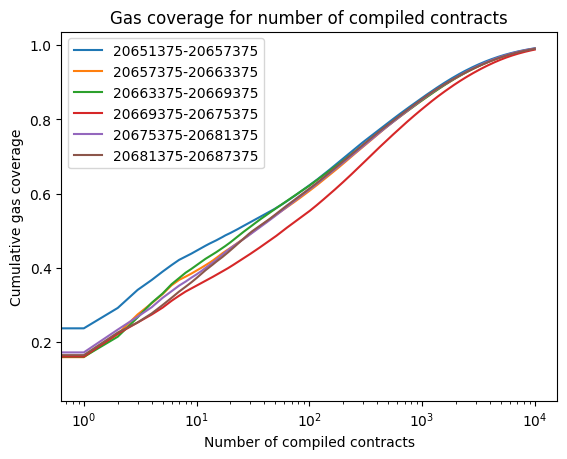

In [5]:
dir = "../.data/measurements-public/gg_coverage/"
dir_elements = os.listdir(dir)
print(f"Found {len(dir_elements)} elements in {dir}")
dir_elements.sort()

for element in dir_elements:
	match = re.search(r'f(\d+)_t(\d+)_', element)
	if not match:
		print(f"Skipping {element}")
		continue
	start_block = match.group(1)
	end_block = match.group(2)

	df = pd.read_json(dir + element)
	df_sorted = df.sort_values(by="prop_gas_used", ascending=False).reset_index(drop=True)
	plt.plot(df_sorted.index, df_sorted['csum_prop_gas_used'], label=f"{start_block}-{end_block}")

plt.xscale("log")
plt.xlabel("Number of compiled contracts")
plt.ylabel("Cumulative gas coverage")
plt.title("Gas coverage for number of compiled contracts")
plt.legend()
plt.show()

In [ ]:
# take into accound how much storage is required